# Exercise 4

## Import packages

In [16]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR

## Task 1
(3 points)

Implement the training loop for one training epoch.
An epoch trains on the whole training dataset once.

In [17]:
def train(model, use_cuda, train_loader, optimizer, epoch, log_interval):
    """
    Train one epoch
    
    model -- the neural network
    use_cuda -- true if GPU should be used
    train_loader -- data loader
    optimizer -- network optimizer
    epoch -- number of current epoch
    log_interval -- number of training steps between logs
    """
    # TODO: set the model to train mode
    model.train()
    
    # TODO: enumerate over the dataloader to get mini batches
    #       of images and ground truth labels
    # HINT: the builtin python function enumerate() also gives you indices
    for batch_idx, (data, target) in enumerate(train_loader):

        if use_cuda:
            data, target = data.cuda(), target.cuda()
        
        # TODO: set the optimizers gradients to zero
        optimizer.zero_grad()
        
        # TODO: run the network
        model_output = model(data)
        
        # TODO: compute negative log likelihood loss
        loss = F.nll_loss(model_output, target)
        
        # TODO: do backpropagation
        loss.backward()
       
        
        # TODO: optimize
        optimizer.step()
        
        # TODO: print current loss for every nth ("log_interval"th) iteration
        if batch_idx % log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))
        

We already implemented the validation function for you (this is essentially validate() from the last exercise)

In [18]:
def validate(model, use_cuda, test_loader):
    """
    Compute test metrics
    
    model -- the neural network
    use_cuda -- true if GPU should be used
    test_loader -- data loader
    """
    # create a 10x10 grid of subplots
    _, axis = plt.subplots(10, 10)
    
    # set model to evaluation mode
    model.eval()
    test_loss = 0
    correct = 0
    plotted = 0
    
    # disable gradients globally
    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(test_loader):
            # for each batch
            if use_cuda:
                # transfer to GPU
                data = data.cuda()
                target = target.cuda()
            
            # run network and compute metrics
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            
            img_correct = pred.eq(target.view_as(pred))
            correct += pred.eq(target.view_as(pred)).sum().item()
            
            # plot the first 100 images
            img_idx = 0
            data = data.cpu().numpy()
            
            while plotted < 100 and img_idx < data.shape[0]:
                # compute position of ith image in the grid
                y = plotted % 10
                x = plotted // 10
                
                # convert image tensor to numpy array and normalize to [0, 1]
                img = data[img_idx, 0]
                img = (img - np.min(img)) / (np.max(img) - np.min(img))
                
                # make wrongly predicted images red
                img = np.stack([img] * 3, 2)
                if img_correct[img_idx] == 0:
                    img[:, :, 1:] = 0.0
                
                # disable axis and show image
                axis[y][x].axis('off')
                axis[y][x].imshow(img)
                
                # show the predicted class next to each image
                axis[y][x].text(30, 25, pred[img_idx].item())
                
                plotted += 1
                img_idx += 1
            
    test_loss /= len(test_loader.dataset)

    # show results
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))
    plt.show()

## Task 2
(4 points)

Implement a five-layer fully connected neural network.
The dimensions (without batch size) should change like this: 784->200->100->60->30->10
Use log softmax to compute the class predictions.

Run the code at the end of the notebook to train and validate your implementation.

### Task 2.1
* sigmoid non-linear activation function
* note that the last layer does not need an activation function!

### Task 2.2
* add a new class "FCNet2"
* replace sigmoid with ReLU

### Task 2.3
* add a new class "FCNet2"
* add batch normalization to the first and third layers (note the difference between 1D/2D/3D versions)


**NOTE:** The perfomance should improve slightly with each step. However, due to the random weight initialization applied by PyTorch, your results may vary a bit between trainings.

In [19]:
class FCNet1(nn.Module):
    """
    Fully Connected Neural Network
    
    Five fully connected layers with sigmoid non-linearity
    
    Dimensions
    784->200->100->60->30->10
    """
    def __init__(self):
        super(FCNet1, self).__init__()
        
        # TODO: initialize network layers
        # HINT: take a look at "torch.nn" (imported as "nn")
        self.fc1 = nn.Linear(784, 200)
        self.fc2 = nn.Linear(200, 100)
        self.fc3 = nn.Linear(100, 60)
        self.fc4 = nn.Linear(60, 30)
        self.fc5 = nn.Linear(30, 10)

       

    def forward(self, x):
        # TODO: reshape batch of images to batch of 1D vectors
        x = x.view(x.size(0), -1)
        
        # TODO: run network layers
        x = torch.sigmoid(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        x = torch.sigmoid(self.fc4(x))
        output = self.fc5(x)
        
        
        # TODO: compute log softmax over the output
        # HINT: take a look at "torch.nn.functional" (imported as "F")
        output = F.log_softmax(output, dim=1)
        
        
        return output

In [27]:
class FCNet2(nn.Module):
    def __init__(self):
        super(FCNet2, self).__init__()

        self.fc1 = nn.Linear(784, 200)
        self.fc2 = nn.Linear(200, 100)
        self.fc3 = nn.Linear(100, 60)
        self.fc4 = nn.Linear(60, 30)
        self.fc5 = nn.Linear(30, 10)
        
    def forward(self, x):
        x = x.view(x.size(0), -1)
        
        #run network layers with relu activations
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        output = self.fc5(x)
        
        #compute softmax over the output
        output = F.log_softmax(output, dim=1)
        
        return output

In [28]:
class FCNet3(nn.Module):
    def __init__(self):
        super(FCNet3, self).__init__()
        # add batch normalization to first layer
        self.fc1 = nn.Linear(784, 200)
        self.bn1 = nn.BatchNorm1d(200)
        self.fc2 = nn.Linear(200, 100)
        #add batch normalization to third layer
        self.fc3 = nn.Linear(100, 60)
        self.bn3 = nn.BatchNorm1d(60)
        self.fc4 = nn.Linear(60, 30)
        self.fc5 = nn.Linear(30, 10)


        
    def forward(self, x):
        x = x.view(x.size(0), -1)
        
        # TODO: run network layers
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        
        x = F.relu(self.fc2(x))
        
        x = self.fc3(x)
        x = self.bn3(x)
        x = F.relu(x)
        
        x = F.relu(self.fc4(x))
        
        output = self.fc5(x)
        
        # Log Softmax
        output = F.log_softmax(output, dim=1)
        
        return output

## Task 3
(3 points)

Implement a convolutional neural network, consisting of two convolutional and two fully connected layers.
This time, the dimensions (without batch size) should change like this: 1x28x28->32x26x26->64x12x12->128->10

### Task 3.1
* two convolutional layers (kernel size 3)
* two fully-connected layers
* ReLU activation function

### Task 3.2
* add batch normalization to first convolutional and first fully connected layer

### Task 3.3
* use max pooling instead of stride to reduce the dimensions to 64x12x12

In [22]:
class ConvNet1(nn.Module):
    """
    Convolutional Neural Network
    
    Two convolutional layers and two fully connected layers
    
    Dimensions:
    1x28x28->32x26x26->64x12x12->128->10
    """
    def __init__(self):
        super(ConvNet1, self).__init__()
        
        # TODO: initialize network layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2)
        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.fc2 = nn.Linear(128, 10)
        

    def forward(self, x):
        # TODO: run convolutional layers
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        
        
        # TODO: reshape batch of images to batch of 1D vectors
        x = x.view(x.size(0), -1)
        
        # TODO: run fully connected layers
        x = F.relu(self.fc1(x))
        output = self.fc2(x)
       
        
        # TODO: compute log softmax over the output
        output = F.log_softmax(output, dim=1)
        
        
        return output

In [23]:
class ConvNet2(nn.Module):
    def __init__(self):
        super(ConvNet2, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2)
        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # TODO: run convolutional layers
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.conv2(x))
        
        
        # TODO: reshape batch of images to batch of 1D vectors
        x = x.view(x.size(0), -1)
        
        # TODO: run fully connected layers
        x = F.relu(self.bn2(self.fc1(x)))
        output = self.fc2(x)
       
        
        # TODO: compute log softmax over the output
        output = F.log_softmax(output, dim=1)
        
        
        return output

In [24]:
class ConvNet3(nn.Module):
    def __init__(self):
        super(ConvNet3, self).__init__()
        # with batch normalization and max pooling instead of stride
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 10)

        

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.bn2(self.fc1(x)))
        output = self.fc2(x)
        output = F.log_softmax(output, dim=1)
        return output

#### Train FCNet1

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.318607
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.304005
Train Epoch: 1 [12800/60000 (21%)]	Loss: 2.285614
Train Epoch: 1 [19200/60000 (32%)]	Loss: 2.320893
Train Epoch: 1 [25600/60000 (43%)]	Loss: 2.303317
Train Epoch: 1 [32000/60000 (53%)]	Loss: 2.285535
Train Epoch: 1 [38400/60000 (64%)]	Loss: 2.312439
Train Epoch: 1 [44800/60000 (75%)]	Loss: 2.277440
Train Epoch: 1 [51200/60000 (85%)]	Loss: 1.857839
Train Epoch: 1 [57600/60000 (96%)]	Loss: 1.709297

Test set: Average loss: 1.5592, Accuracy: 3591/10000 (35.91%)



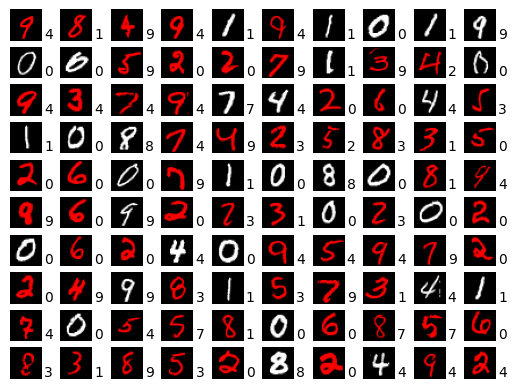

Train Epoch: 2 [0/60000 (0%)]	Loss: 1.436962
Train Epoch: 2 [6400/60000 (11%)]	Loss: 1.377954
Train Epoch: 2 [12800/60000 (21%)]	Loss: 1.314013
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.966881
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.952160
Train Epoch: 2 [32000/60000 (53%)]	Loss: 1.051011
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.576467
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.744327
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.544591
Train Epoch: 2 [57600/60000 (96%)]	Loss: 0.606565

Test set: Average loss: 0.5543, Accuracy: 8560/10000 (85.60%)



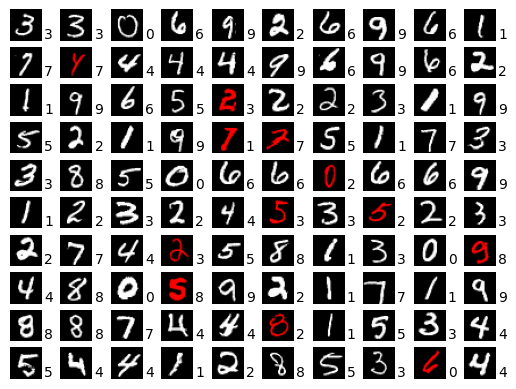

Train Epoch: 3 [0/60000 (0%)]	Loss: 0.558047
Train Epoch: 3 [6400/60000 (11%)]	Loss: 0.506083
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.387769
Train Epoch: 3 [19200/60000 (32%)]	Loss: 0.572340
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.359939
Train Epoch: 3 [32000/60000 (53%)]	Loss: 0.381331
Train Epoch: 3 [38400/60000 (64%)]	Loss: 0.260001
Train Epoch: 3 [44800/60000 (75%)]	Loss: 0.349923
Train Epoch: 3 [51200/60000 (85%)]	Loss: 0.404759
Train Epoch: 3 [57600/60000 (96%)]	Loss: 0.395219

Test set: Average loss: 0.3065, Accuracy: 9286/10000 (92.86%)



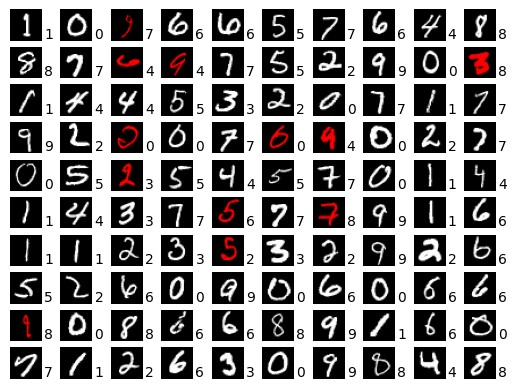

Train Epoch: 4 [0/60000 (0%)]	Loss: 0.391611
Train Epoch: 4 [6400/60000 (11%)]	Loss: 0.091358
Train Epoch: 4 [12800/60000 (21%)]	Loss: 0.186785
Train Epoch: 4 [19200/60000 (32%)]	Loss: 0.401373
Train Epoch: 4 [25600/60000 (43%)]	Loss: 0.169414
Train Epoch: 4 [32000/60000 (53%)]	Loss: 0.221071
Train Epoch: 4 [38400/60000 (64%)]	Loss: 0.156838
Train Epoch: 4 [44800/60000 (75%)]	Loss: 0.482280
Train Epoch: 4 [51200/60000 (85%)]	Loss: 0.466938
Train Epoch: 4 [57600/60000 (96%)]	Loss: 0.355481

Test set: Average loss: 0.2478, Accuracy: 9397/10000 (93.97%)



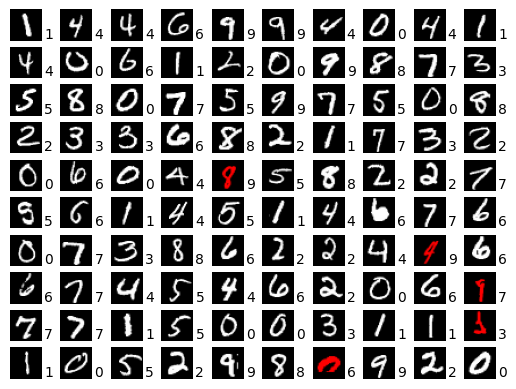

Train Epoch: 5 [0/60000 (0%)]	Loss: 0.145761
Train Epoch: 5 [6400/60000 (11%)]	Loss: 0.224286
Train Epoch: 5 [12800/60000 (21%)]	Loss: 0.348603
Train Epoch: 5 [19200/60000 (32%)]	Loss: 0.140525
Train Epoch: 5 [25600/60000 (43%)]	Loss: 0.152892
Train Epoch: 5 [32000/60000 (53%)]	Loss: 0.293184
Train Epoch: 5 [38400/60000 (64%)]	Loss: 0.290703
Train Epoch: 5 [44800/60000 (75%)]	Loss: 0.157998
Train Epoch: 5 [51200/60000 (85%)]	Loss: 0.192973
Train Epoch: 5 [57600/60000 (96%)]	Loss: 0.152636

Test set: Average loss: 0.2232, Accuracy: 9491/10000 (94.91%)



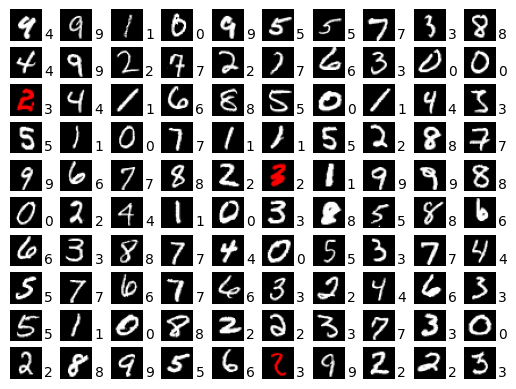

Train Epoch: 6 [0/60000 (0%)]	Loss: 0.172090
Train Epoch: 6 [6400/60000 (11%)]	Loss: 0.197948
Train Epoch: 6 [12800/60000 (21%)]	Loss: 0.161647
Train Epoch: 6 [19200/60000 (32%)]	Loss: 0.133035
Train Epoch: 6 [25600/60000 (43%)]	Loss: 0.192374
Train Epoch: 6 [32000/60000 (53%)]	Loss: 0.078991
Train Epoch: 6 [38400/60000 (64%)]	Loss: 0.086799
Train Epoch: 6 [44800/60000 (75%)]	Loss: 0.193619
Train Epoch: 6 [51200/60000 (85%)]	Loss: 0.098032
Train Epoch: 6 [57600/60000 (96%)]	Loss: 0.071515

Test set: Average loss: 0.2244, Accuracy: 9464/10000 (94.64%)



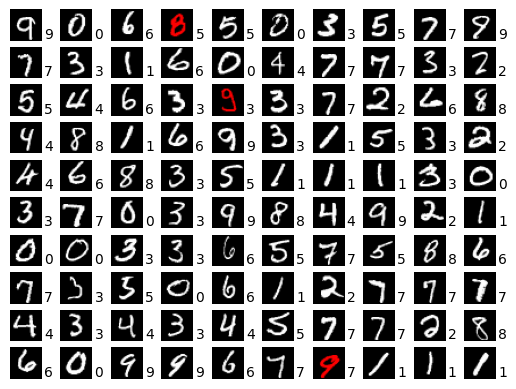

Train Epoch: 7 [0/60000 (0%)]	Loss: 0.109563
Train Epoch: 7 [6400/60000 (11%)]	Loss: 0.248088
Train Epoch: 7 [12800/60000 (21%)]	Loss: 0.087611
Train Epoch: 7 [19200/60000 (32%)]	Loss: 0.073223
Train Epoch: 7 [25600/60000 (43%)]	Loss: 0.134206
Train Epoch: 7 [32000/60000 (53%)]	Loss: 0.212913
Train Epoch: 7 [38400/60000 (64%)]	Loss: 0.195102
Train Epoch: 7 [44800/60000 (75%)]	Loss: 0.108024
Train Epoch: 7 [51200/60000 (85%)]	Loss: 0.224821
Train Epoch: 7 [57600/60000 (96%)]	Loss: 0.378331

Test set: Average loss: 0.2024, Accuracy: 9519/10000 (95.19%)



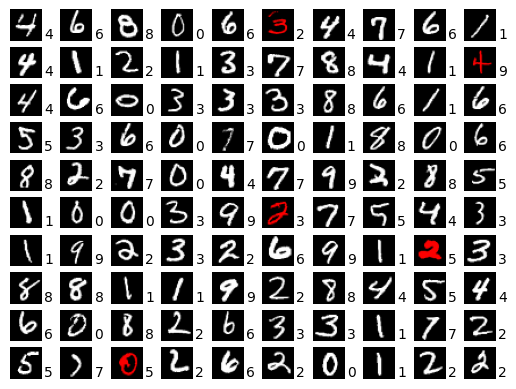

Train Epoch: 8 [0/60000 (0%)]	Loss: 0.177827
Train Epoch: 8 [6400/60000 (11%)]	Loss: 0.126563
Train Epoch: 8 [12800/60000 (21%)]	Loss: 0.060282
Train Epoch: 8 [19200/60000 (32%)]	Loss: 0.099655
Train Epoch: 8 [25600/60000 (43%)]	Loss: 0.338929
Train Epoch: 8 [32000/60000 (53%)]	Loss: 0.178017
Train Epoch: 8 [38400/60000 (64%)]	Loss: 0.220774
Train Epoch: 8 [44800/60000 (75%)]	Loss: 0.102299
Train Epoch: 8 [51200/60000 (85%)]	Loss: 0.142972
Train Epoch: 8 [57600/60000 (96%)]	Loss: 0.137840

Test set: Average loss: 0.2021, Accuracy: 9527/10000 (95.27%)



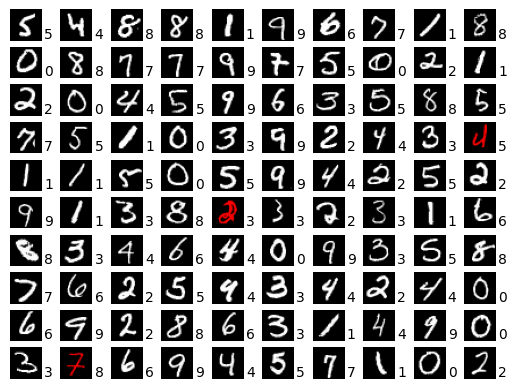

Train Epoch: 9 [0/60000 (0%)]	Loss: 0.111420
Train Epoch: 9 [6400/60000 (11%)]	Loss: 0.097237
Train Epoch: 9 [12800/60000 (21%)]	Loss: 0.122167
Train Epoch: 9 [19200/60000 (32%)]	Loss: 0.050673
Train Epoch: 9 [25600/60000 (43%)]	Loss: 0.157651
Train Epoch: 9 [32000/60000 (53%)]	Loss: 0.081356
Train Epoch: 9 [38400/60000 (64%)]	Loss: 0.095485
Train Epoch: 9 [44800/60000 (75%)]	Loss: 0.056518
Train Epoch: 9 [51200/60000 (85%)]	Loss: 0.082151
Train Epoch: 9 [57600/60000 (96%)]	Loss: 0.123048

Test set: Average loss: 0.1955, Accuracy: 9527/10000 (95.27%)



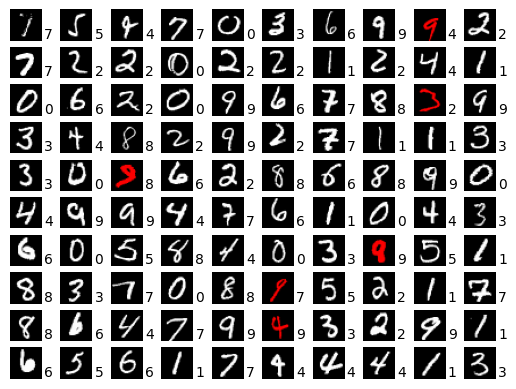

Train Epoch: 10 [0/60000 (0%)]	Loss: 0.214964
Train Epoch: 10 [6400/60000 (11%)]	Loss: 0.117943
Train Epoch: 10 [12800/60000 (21%)]	Loss: 0.049644
Train Epoch: 10 [19200/60000 (32%)]	Loss: 0.039100
Train Epoch: 10 [25600/60000 (43%)]	Loss: 0.207666
Train Epoch: 10 [32000/60000 (53%)]	Loss: 0.148192
Train Epoch: 10 [38400/60000 (64%)]	Loss: 0.112752
Train Epoch: 10 [44800/60000 (75%)]	Loss: 0.204154
Train Epoch: 10 [51200/60000 (85%)]	Loss: 0.140596
Train Epoch: 10 [57600/60000 (96%)]	Loss: 0.059743

Test set: Average loss: 0.1925, Accuracy: 9559/10000 (95.59%)



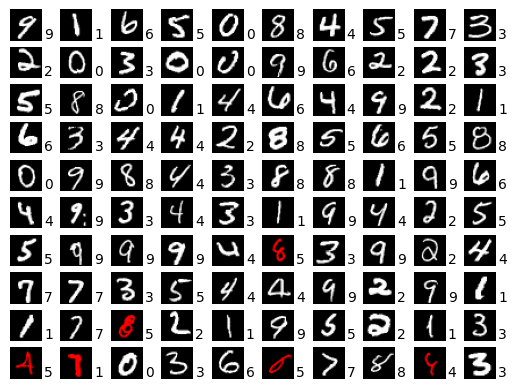

In [26]:
# hyper parameters
batch_size = 64
test_batch_size = 1000
epochs = 10
lr = 1.0
gamma = 0.7
log_interval = 100

# use GPU if available
use_cuda = torch.cuda.is_available()
kwargs = {'num_workers': 1, 'pin_memory': True} if use_cuda else {}

# initialize data loaders
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=True, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])), batch_size=batch_size, shuffle=True, **kwargs)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=False, 
    transform=transforms.Compose([
        transforms.ToTensor(), 
        transforms.Normalize((0.1307,), (0.3081,))
    ])),
    batch_size=test_batch_size, shuffle=True, **kwargs)

model = FCNet1()
if use_cuda:
    model = model.cuda()

# initialize optimizer and scheduler
optimizer = optim.Adadelta(model.parameters(), lr=lr)
scheduler = StepLR(optimizer, step_size=1, gamma=gamma)

for epoch in range(1, epochs + 1):
    # train one epoch
    train(model, use_cuda, train_loader, optimizer, epoch, log_interval)
    
    # run on test dataset
    validate(model, use_cuda, test_loader)
    scheduler.step()
    
    
    torch.save(model.state_dict(), "models/mnist/fcnet1_checkpoint.pt")

#### Train FCNet2

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.332311
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.582294
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.498149
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.378822
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.087986
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.159702
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.042538
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.247716
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.009894
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.115831

Test set: Average loss: 0.1191, Accuracy: 9653/10000 (96.53%)



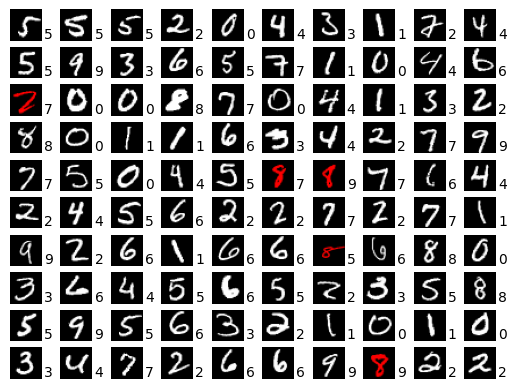

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.257898
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.163578
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.126628
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.063378
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.071768
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.053624
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.056609
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.161547
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.019115
Train Epoch: 2 [57600/60000 (96%)]	Loss: 0.130636

Test set: Average loss: 0.0835, Accuracy: 9773/10000 (97.73%)



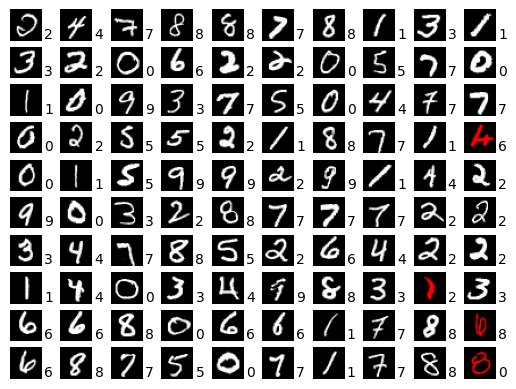

Train Epoch: 3 [0/60000 (0%)]	Loss: 0.091805
Train Epoch: 3 [6400/60000 (11%)]	Loss: 0.018892
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.000825
Train Epoch: 3 [19200/60000 (32%)]	Loss: 0.000582
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.016005
Train Epoch: 3 [32000/60000 (53%)]	Loss: 0.017865
Train Epoch: 3 [38400/60000 (64%)]	Loss: 0.030544
Train Epoch: 3 [44800/60000 (75%)]	Loss: 0.123489
Train Epoch: 3 [51200/60000 (85%)]	Loss: 0.075371
Train Epoch: 3 [57600/60000 (96%)]	Loss: 0.007213

Test set: Average loss: 0.0804, Accuracy: 9786/10000 (97.86%)



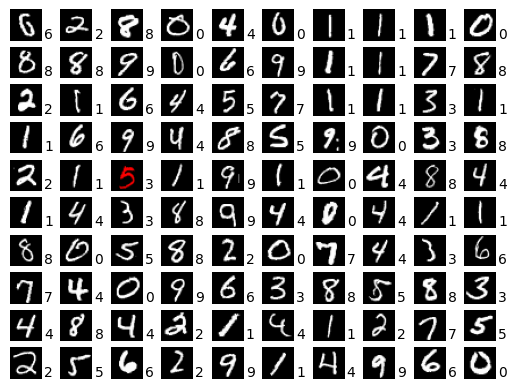

Train Epoch: 4 [0/60000 (0%)]	Loss: 0.016235
Train Epoch: 4 [6400/60000 (11%)]	Loss: 0.008694
Train Epoch: 4 [12800/60000 (21%)]	Loss: 0.051224
Train Epoch: 4 [19200/60000 (32%)]	Loss: 0.026256
Train Epoch: 4 [25600/60000 (43%)]	Loss: 0.011762
Train Epoch: 4 [32000/60000 (53%)]	Loss: 0.041665
Train Epoch: 4 [38400/60000 (64%)]	Loss: 0.006180
Train Epoch: 4 [44800/60000 (75%)]	Loss: 0.000620
Train Epoch: 4 [51200/60000 (85%)]	Loss: 0.011324
Train Epoch: 4 [57600/60000 (96%)]	Loss: 0.010434

Test set: Average loss: 0.0719, Accuracy: 9808/10000 (98.08%)



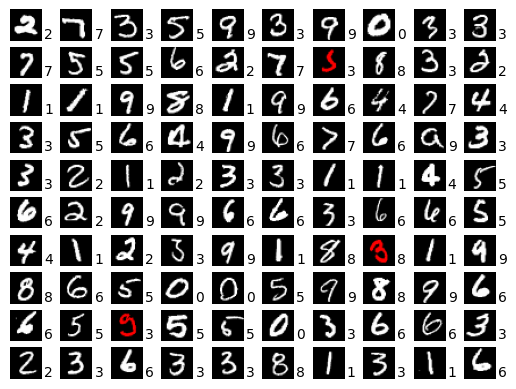

Train Epoch: 5 [0/60000 (0%)]	Loss: 0.000506
Train Epoch: 5 [6400/60000 (11%)]	Loss: 0.008172
Train Epoch: 5 [12800/60000 (21%)]	Loss: 0.000736
Train Epoch: 5 [19200/60000 (32%)]	Loss: 0.003854
Train Epoch: 5 [25600/60000 (43%)]	Loss: 0.000276
Train Epoch: 5 [32000/60000 (53%)]	Loss: 0.039926
Train Epoch: 5 [38400/60000 (64%)]	Loss: 0.017926
Train Epoch: 5 [44800/60000 (75%)]	Loss: 0.001474
Train Epoch: 5 [51200/60000 (85%)]	Loss: 0.127992
Train Epoch: 5 [57600/60000 (96%)]	Loss: 0.005344

Test set: Average loss: 0.0745, Accuracy: 9822/10000 (98.22%)



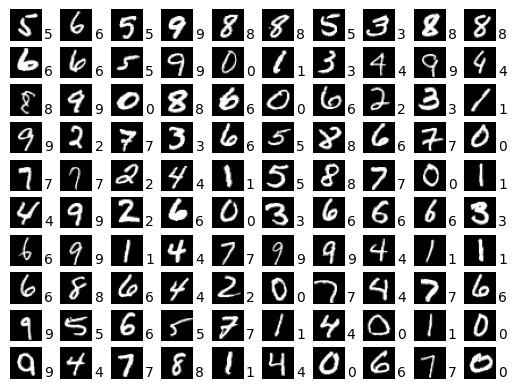

Train Epoch: 6 [0/60000 (0%)]	Loss: 0.002777
Train Epoch: 6 [6400/60000 (11%)]	Loss: 0.000197
Train Epoch: 6 [12800/60000 (21%)]	Loss: 0.000315
Train Epoch: 6 [19200/60000 (32%)]	Loss: 0.006603
Train Epoch: 6 [25600/60000 (43%)]	Loss: 0.000529
Train Epoch: 6 [32000/60000 (53%)]	Loss: 0.021878
Train Epoch: 6 [38400/60000 (64%)]	Loss: 0.035585
Train Epoch: 6 [44800/60000 (75%)]	Loss: 0.001231
Train Epoch: 6 [51200/60000 (85%)]	Loss: 0.004233
Train Epoch: 6 [57600/60000 (96%)]	Loss: 0.059918

Test set: Average loss: 0.0793, Accuracy: 9817/10000 (98.17%)



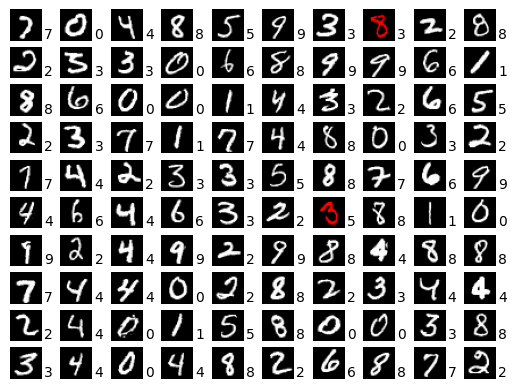

Train Epoch: 7 [0/60000 (0%)]	Loss: 0.000593
Train Epoch: 7 [6400/60000 (11%)]	Loss: 0.019892
Train Epoch: 7 [12800/60000 (21%)]	Loss: 0.043328
Train Epoch: 7 [19200/60000 (32%)]	Loss: 0.001228
Train Epoch: 7 [25600/60000 (43%)]	Loss: 0.001290
Train Epoch: 7 [32000/60000 (53%)]	Loss: 0.001006
Train Epoch: 7 [38400/60000 (64%)]	Loss: 0.007433
Train Epoch: 7 [44800/60000 (75%)]	Loss: 0.000369
Train Epoch: 7 [51200/60000 (85%)]	Loss: 0.001064
Train Epoch: 7 [57600/60000 (96%)]	Loss: 0.000744

Test set: Average loss: 0.0824, Accuracy: 9820/10000 (98.20%)



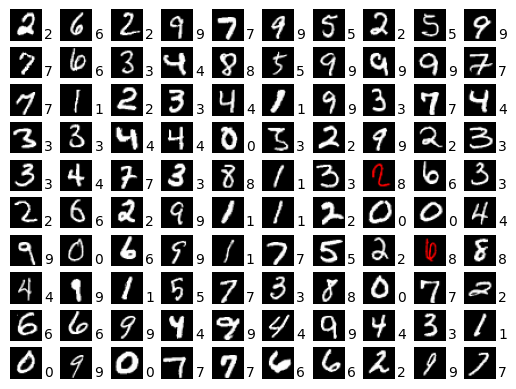

Train Epoch: 8 [0/60000 (0%)]	Loss: 0.106901
Train Epoch: 8 [6400/60000 (11%)]	Loss: 0.000395
Train Epoch: 8 [12800/60000 (21%)]	Loss: 0.002812
Train Epoch: 8 [19200/60000 (32%)]	Loss: 0.000072
Train Epoch: 8 [25600/60000 (43%)]	Loss: 0.000858
Train Epoch: 8 [32000/60000 (53%)]	Loss: 0.001996
Train Epoch: 8 [38400/60000 (64%)]	Loss: 0.035198
Train Epoch: 8 [44800/60000 (75%)]	Loss: 0.000052
Train Epoch: 8 [51200/60000 (85%)]	Loss: 0.175299
Train Epoch: 8 [57600/60000 (96%)]	Loss: 0.004290

Test set: Average loss: 0.0837, Accuracy: 9820/10000 (98.20%)



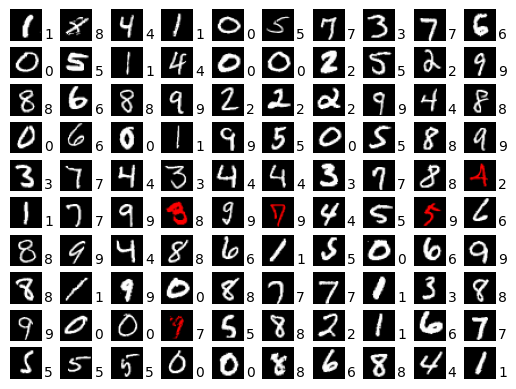

Train Epoch: 9 [0/60000 (0%)]	Loss: 0.001117
Train Epoch: 9 [6400/60000 (11%)]	Loss: 0.008009
Train Epoch: 9 [12800/60000 (21%)]	Loss: 0.000719
Train Epoch: 9 [19200/60000 (32%)]	Loss: 0.004588
Train Epoch: 9 [25600/60000 (43%)]	Loss: 0.001399
Train Epoch: 9 [32000/60000 (53%)]	Loss: 0.000427
Train Epoch: 9 [38400/60000 (64%)]	Loss: 0.000156
Train Epoch: 9 [44800/60000 (75%)]	Loss: 0.091129
Train Epoch: 9 [51200/60000 (85%)]	Loss: 0.000074
Train Epoch: 9 [57600/60000 (96%)]	Loss: 0.000262

Test set: Average loss: 0.0834, Accuracy: 9817/10000 (98.17%)



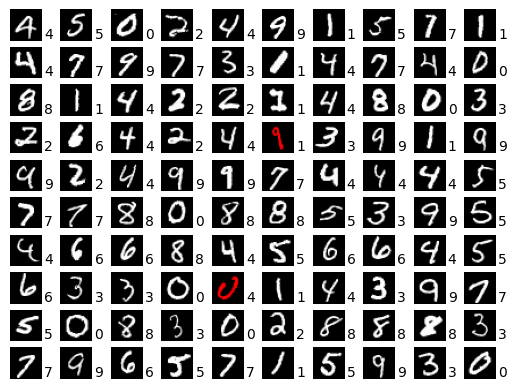

Train Epoch: 10 [0/60000 (0%)]	Loss: 0.000104
Train Epoch: 10 [6400/60000 (11%)]	Loss: 0.010718
Train Epoch: 10 [12800/60000 (21%)]	Loss: 0.000213
Train Epoch: 10 [19200/60000 (32%)]	Loss: 0.251151
Train Epoch: 10 [25600/60000 (43%)]	Loss: 0.000815
Train Epoch: 10 [32000/60000 (53%)]	Loss: 0.004517
Train Epoch: 10 [38400/60000 (64%)]	Loss: 0.023025
Train Epoch: 10 [44800/60000 (75%)]	Loss: 0.000718
Train Epoch: 10 [51200/60000 (85%)]	Loss: 0.000399
Train Epoch: 10 [57600/60000 (96%)]	Loss: 0.003500

Test set: Average loss: 0.0850, Accuracy: 9825/10000 (98.25%)



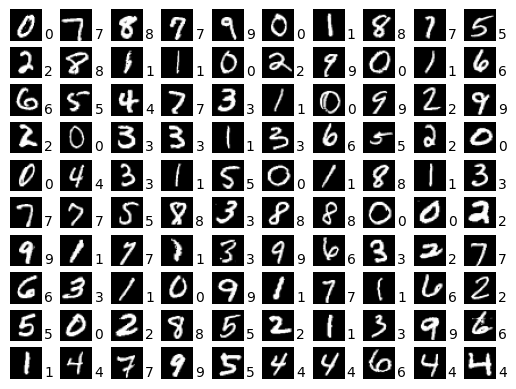

In [29]:
# hyper parameters
batch_size = 64
test_batch_size = 1000
epochs = 10
lr = 1.0
gamma = 0.7
log_interval = 100

# use GPU if available
use_cuda = torch.cuda.is_available()
kwargs = {'num_workers': 1, 'pin_memory': True} if use_cuda else {}

# initialize data loaders
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=True, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])), batch_size=batch_size, shuffle=True, **kwargs)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=False, 
    transform=transforms.Compose([
        transforms.ToTensor(), 
        transforms.Normalize((0.1307,), (0.3081,))
    ])),
    batch_size=test_batch_size, shuffle=True, **kwargs)

model = FCNet2()
if use_cuda:
    model = model.cuda()

# initialize optimizer and scheduler
optimizer = optim.Adadelta(model.parameters(), lr=lr)
scheduler = StepLR(optimizer, step_size=1, gamma=gamma)

for epoch in range(1, epochs + 1):
    # train one epoch
    train(model, use_cuda, train_loader, optimizer, epoch, log_interval)
    
    # run on test dataset
    validate(model, use_cuda, test_loader)
    scheduler.step()
    
    
    torch.save(model.state_dict(), "models/mnist/fcnet2_checkpoint.pt")

#### Train FCNet3

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.313363
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.288334
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.216082
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.139373
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.105999
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.172060
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.177206
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.048524
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.076380
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.340872

Test set: Average loss: 0.1278, Accuracy: 9612/10000 (96.12%)



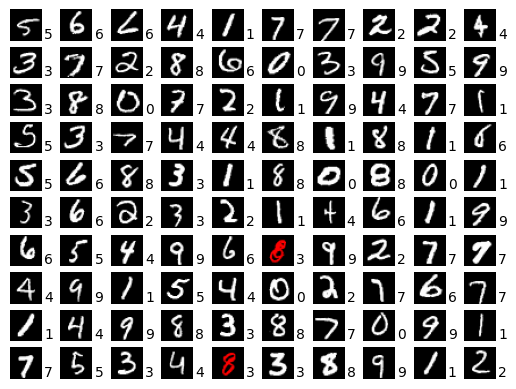

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.087502
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.124915
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.095301
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.042841
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.049667
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.044532
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.114184
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.096871
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.056335
Train Epoch: 2 [57600/60000 (96%)]	Loss: 0.070385

Test set: Average loss: 0.0783, Accuracy: 9758/10000 (97.58%)



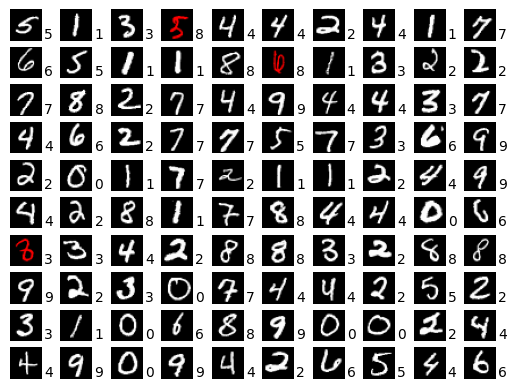

Train Epoch: 3 [0/60000 (0%)]	Loss: 0.018672
Train Epoch: 3 [6400/60000 (11%)]	Loss: 0.092935
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.047225
Train Epoch: 3 [19200/60000 (32%)]	Loss: 0.039840
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.026424
Train Epoch: 3 [32000/60000 (53%)]	Loss: 0.007702
Train Epoch: 3 [38400/60000 (64%)]	Loss: 0.039416
Train Epoch: 3 [44800/60000 (75%)]	Loss: 0.034719
Train Epoch: 3 [51200/60000 (85%)]	Loss: 0.004522
Train Epoch: 3 [57600/60000 (96%)]	Loss: 0.102125

Test set: Average loss: 0.0625, Accuracy: 9805/10000 (98.05%)



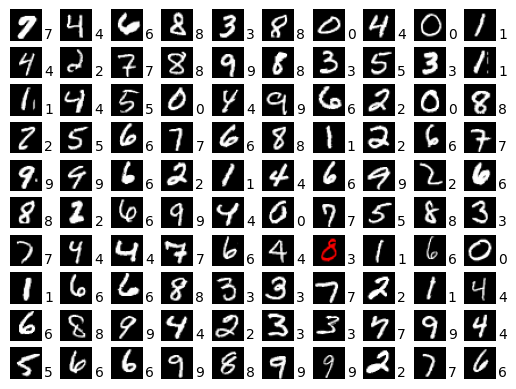

Train Epoch: 4 [0/60000 (0%)]	Loss: 0.035961
Train Epoch: 4 [6400/60000 (11%)]	Loss: 0.088349
Train Epoch: 4 [12800/60000 (21%)]	Loss: 0.110381
Train Epoch: 4 [19200/60000 (32%)]	Loss: 0.134349
Train Epoch: 4 [25600/60000 (43%)]	Loss: 0.085592
Train Epoch: 4 [32000/60000 (53%)]	Loss: 0.023032
Train Epoch: 4 [38400/60000 (64%)]	Loss: 0.013639
Train Epoch: 4 [44800/60000 (75%)]	Loss: 0.045970
Train Epoch: 4 [51200/60000 (85%)]	Loss: 0.005765
Train Epoch: 4 [57600/60000 (96%)]	Loss: 0.008354

Test set: Average loss: 0.0605, Accuracy: 9822/10000 (98.22%)



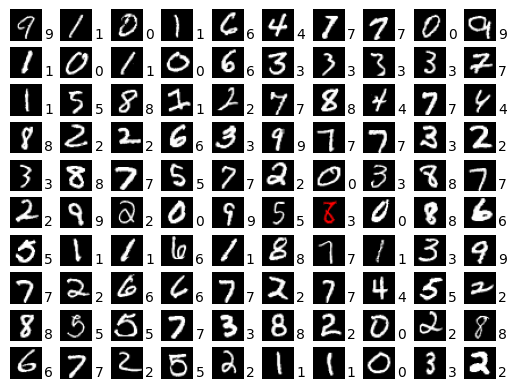

Train Epoch: 5 [0/60000 (0%)]	Loss: 0.003351
Train Epoch: 5 [6400/60000 (11%)]	Loss: 0.104384
Train Epoch: 5 [12800/60000 (21%)]	Loss: 0.100916
Train Epoch: 5 [19200/60000 (32%)]	Loss: 0.010061
Train Epoch: 5 [25600/60000 (43%)]	Loss: 0.002760
Train Epoch: 5 [32000/60000 (53%)]	Loss: 0.098488
Train Epoch: 5 [38400/60000 (64%)]	Loss: 0.007003
Train Epoch: 5 [44800/60000 (75%)]	Loss: 0.063376
Train Epoch: 5 [51200/60000 (85%)]	Loss: 0.003034
Train Epoch: 5 [57600/60000 (96%)]	Loss: 0.006579

Test set: Average loss: 0.0589, Accuracy: 9831/10000 (98.31%)



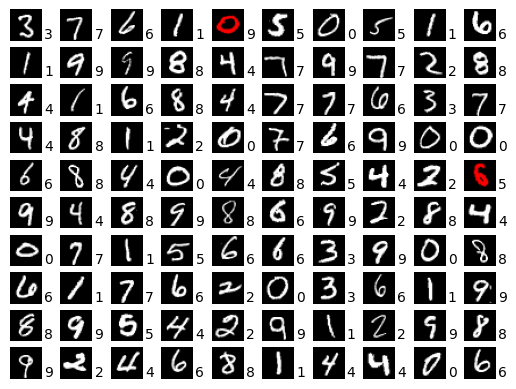

Train Epoch: 6 [0/60000 (0%)]	Loss: 0.070718
Train Epoch: 6 [6400/60000 (11%)]	Loss: 0.019394
Train Epoch: 6 [12800/60000 (21%)]	Loss: 0.001817
Train Epoch: 6 [19200/60000 (32%)]	Loss: 0.000708
Train Epoch: 6 [25600/60000 (43%)]	Loss: 0.002668
Train Epoch: 6 [32000/60000 (53%)]	Loss: 0.051088
Train Epoch: 6 [38400/60000 (64%)]	Loss: 0.035101
Train Epoch: 6 [44800/60000 (75%)]	Loss: 0.010306
Train Epoch: 6 [51200/60000 (85%)]	Loss: 0.022361
Train Epoch: 6 [57600/60000 (96%)]	Loss: 0.002363

Test set: Average loss: 0.0549, Accuracy: 9858/10000 (98.58%)



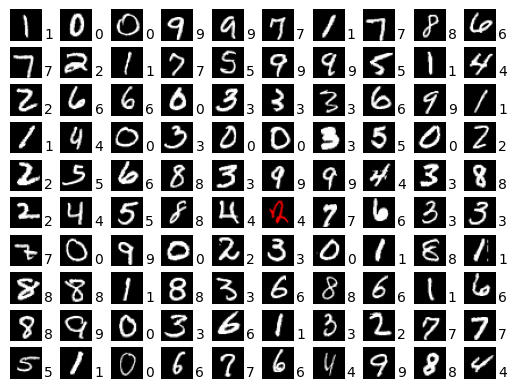

Train Epoch: 7 [0/60000 (0%)]	Loss: 0.004519
Train Epoch: 7 [6400/60000 (11%)]	Loss: 0.005418
Train Epoch: 7 [12800/60000 (21%)]	Loss: 0.019712
Train Epoch: 7 [19200/60000 (32%)]	Loss: 0.016821
Train Epoch: 7 [25600/60000 (43%)]	Loss: 0.006680
Train Epoch: 7 [32000/60000 (53%)]	Loss: 0.007398
Train Epoch: 7 [38400/60000 (64%)]	Loss: 0.072938
Train Epoch: 7 [44800/60000 (75%)]	Loss: 0.002064
Train Epoch: 7 [51200/60000 (85%)]	Loss: 0.010343
Train Epoch: 7 [57600/60000 (96%)]	Loss: 0.004761

Test set: Average loss: 0.0552, Accuracy: 9851/10000 (98.51%)



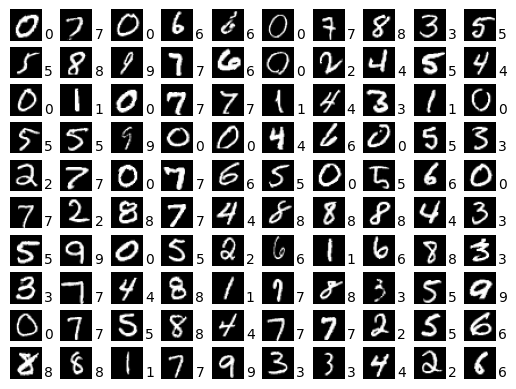

Train Epoch: 8 [0/60000 (0%)]	Loss: 0.014472
Train Epoch: 8 [6400/60000 (11%)]	Loss: 0.006247
Train Epoch: 8 [12800/60000 (21%)]	Loss: 0.005512
Train Epoch: 8 [19200/60000 (32%)]	Loss: 0.000466
Train Epoch: 8 [25600/60000 (43%)]	Loss: 0.076256
Train Epoch: 8 [32000/60000 (53%)]	Loss: 0.002170
Train Epoch: 8 [38400/60000 (64%)]	Loss: 0.000956
Train Epoch: 8 [44800/60000 (75%)]	Loss: 0.002094
Train Epoch: 8 [51200/60000 (85%)]	Loss: 0.076523
Train Epoch: 8 [57600/60000 (96%)]	Loss: 0.003138

Test set: Average loss: 0.0541, Accuracy: 9850/10000 (98.50%)



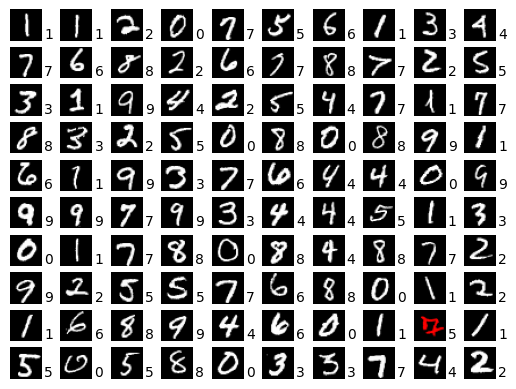

Train Epoch: 9 [0/60000 (0%)]	Loss: 0.016251
Train Epoch: 9 [6400/60000 (11%)]	Loss: 0.034642
Train Epoch: 9 [12800/60000 (21%)]	Loss: 0.074113
Train Epoch: 9 [19200/60000 (32%)]	Loss: 0.006478
Train Epoch: 9 [25600/60000 (43%)]	Loss: 0.000854
Train Epoch: 9 [32000/60000 (53%)]	Loss: 0.013223
Train Epoch: 9 [38400/60000 (64%)]	Loss: 0.001134
Train Epoch: 9 [44800/60000 (75%)]	Loss: 0.022208
Train Epoch: 9 [51200/60000 (85%)]	Loss: 0.011395
Train Epoch: 9 [57600/60000 (96%)]	Loss: 0.004520

Test set: Average loss: 0.0579, Accuracy: 9851/10000 (98.51%)



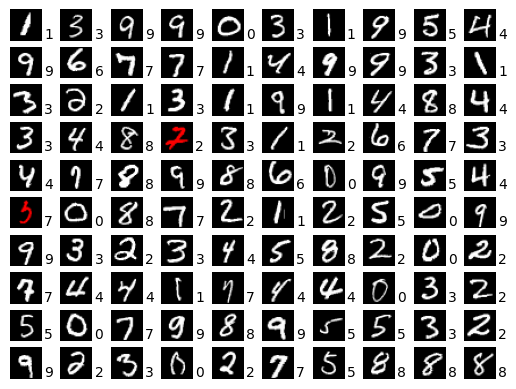

Train Epoch: 10 [0/60000 (0%)]	Loss: 0.021562
Train Epoch: 10 [6400/60000 (11%)]	Loss: 0.016642
Train Epoch: 10 [12800/60000 (21%)]	Loss: 0.010203
Train Epoch: 10 [19200/60000 (32%)]	Loss: 0.000331
Train Epoch: 10 [25600/60000 (43%)]	Loss: 0.000104
Train Epoch: 10 [32000/60000 (53%)]	Loss: 0.002416
Train Epoch: 10 [38400/60000 (64%)]	Loss: 0.001118
Train Epoch: 10 [44800/60000 (75%)]	Loss: 0.020741
Train Epoch: 10 [51200/60000 (85%)]	Loss: 0.029319
Train Epoch: 10 [57600/60000 (96%)]	Loss: 0.005636

Test set: Average loss: 0.0569, Accuracy: 9841/10000 (98.41%)



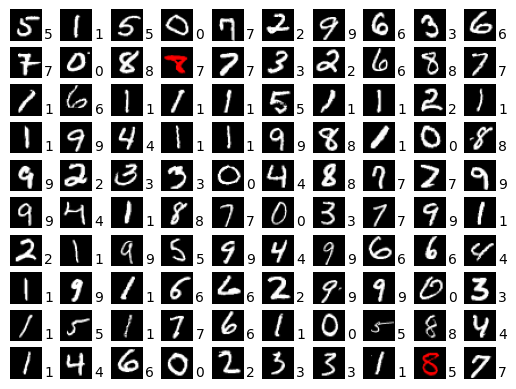

In [30]:
# hyper parameters
batch_size = 64
test_batch_size = 1000
epochs = 10
lr = 1.0
gamma = 0.7
log_interval = 100

# use GPU if available
use_cuda = torch.cuda.is_available()
kwargs = {'num_workers': 1, 'pin_memory': True} if use_cuda else {}

# initialize data loaders
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=True, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])), batch_size=batch_size, shuffle=True, **kwargs)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=False, 
    transform=transforms.Compose([
        transforms.ToTensor(), 
        transforms.Normalize((0.1307,), (0.3081,))
    ])),
    batch_size=test_batch_size, shuffle=True, **kwargs)

model = FCNet3()
if use_cuda:
    model = model.cuda()

# initialize optimizer and scheduler
optimizer = optim.Adadelta(model.parameters(), lr=lr)
scheduler = StepLR(optimizer, step_size=1, gamma=gamma)

for epoch in range(1, epochs + 1):
    # train one epoch
    train(model, use_cuda, train_loader, optimizer, epoch, log_interval)
    
    # run on test dataset
    validate(model, use_cuda, test_loader)
    scheduler.step()
    
    
    torch.save(model.state_dict(), "models/mnist/fcnet3_checkpoint.pt")

#### Train ConvNet1

False
Train Epoch: 1 [0/60000 (0%)]	Loss: 2.293239
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.146975
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.085706
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.057216
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.189787
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.018761
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.090599
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.018296
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.049352
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.010371

Test set: Average loss: 0.0496, Accuracy: 9843/10000 (98.43%)



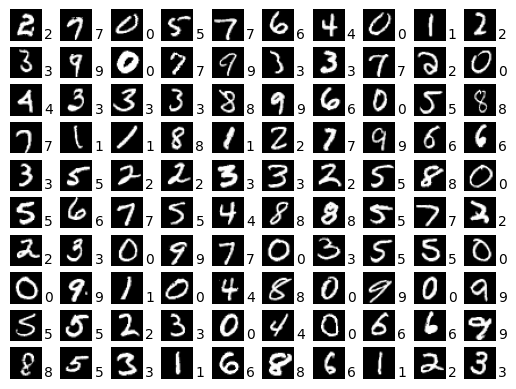

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.019076
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.011390
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.004136
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.006882
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.014162
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.113401
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.133214
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.031637
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.017651
Train Epoch: 2 [57600/60000 (96%)]	Loss: 0.030289

Test set: Average loss: 0.0337, Accuracy: 9895/10000 (98.95%)



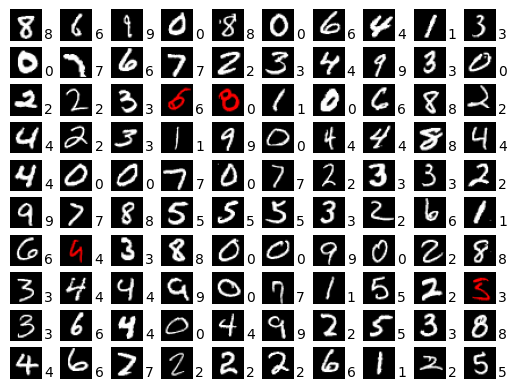

Train Epoch: 3 [0/60000 (0%)]	Loss: 0.006912
Train Epoch: 3 [6400/60000 (11%)]	Loss: 0.044240
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.001058
Train Epoch: 3 [19200/60000 (32%)]	Loss: 0.002568
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.004053
Train Epoch: 3 [32000/60000 (53%)]	Loss: 0.025204
Train Epoch: 3 [38400/60000 (64%)]	Loss: 0.000682
Train Epoch: 3 [44800/60000 (75%)]	Loss: 0.006198
Train Epoch: 3 [51200/60000 (85%)]	Loss: 0.007099
Train Epoch: 3 [57600/60000 (96%)]	Loss: 0.003459

Test set: Average loss: 0.0338, Accuracy: 9899/10000 (98.99%)



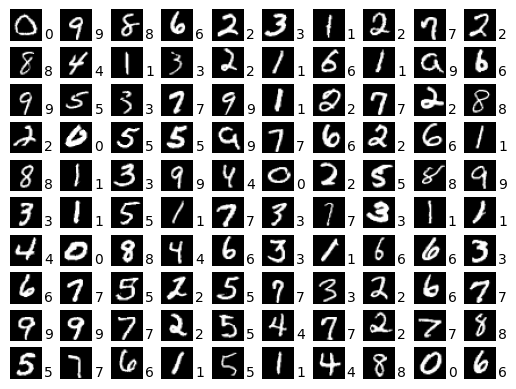

Train Epoch: 4 [0/60000 (0%)]	Loss: 0.002877
Train Epoch: 4 [6400/60000 (11%)]	Loss: 0.000489
Train Epoch: 4 [12800/60000 (21%)]	Loss: 0.000632
Train Epoch: 4 [19200/60000 (32%)]	Loss: 0.000897
Train Epoch: 4 [25600/60000 (43%)]	Loss: 0.001949
Train Epoch: 4 [32000/60000 (53%)]	Loss: 0.002077
Train Epoch: 4 [38400/60000 (64%)]	Loss: 0.000540
Train Epoch: 4 [44800/60000 (75%)]	Loss: 0.000283
Train Epoch: 4 [51200/60000 (85%)]	Loss: 0.000196
Train Epoch: 4 [57600/60000 (96%)]	Loss: 0.001785

Test set: Average loss: 0.0350, Accuracy: 9901/10000 (99.01%)



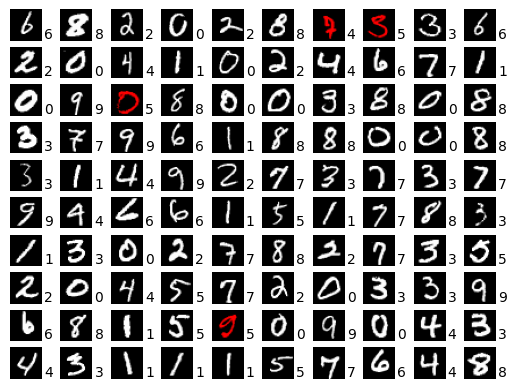

Train Epoch: 5 [0/60000 (0%)]	Loss: 0.095477
Train Epoch: 5 [6400/60000 (11%)]	Loss: 0.000121
Train Epoch: 5 [12800/60000 (21%)]	Loss: 0.002682
Train Epoch: 5 [19200/60000 (32%)]	Loss: 0.000266
Train Epoch: 5 [25600/60000 (43%)]	Loss: 0.001246
Train Epoch: 5 [32000/60000 (53%)]	Loss: 0.000679
Train Epoch: 5 [38400/60000 (64%)]	Loss: 0.000095
Train Epoch: 5 [44800/60000 (75%)]	Loss: 0.000488
Train Epoch: 5 [51200/60000 (85%)]	Loss: 0.000092
Train Epoch: 5 [57600/60000 (96%)]	Loss: 0.000775

Test set: Average loss: 0.0379, Accuracy: 9902/10000 (99.02%)



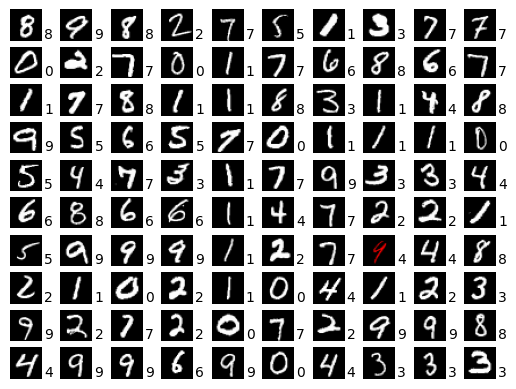

Train Epoch: 6 [0/60000 (0%)]	Loss: 0.009877
Train Epoch: 6 [6400/60000 (11%)]	Loss: 0.000555
Train Epoch: 6 [12800/60000 (21%)]	Loss: 0.001825
Train Epoch: 6 [19200/60000 (32%)]	Loss: 0.001438
Train Epoch: 6 [25600/60000 (43%)]	Loss: 0.000315
Train Epoch: 6 [32000/60000 (53%)]	Loss: 0.011713
Train Epoch: 6 [38400/60000 (64%)]	Loss: 0.001681
Train Epoch: 6 [44800/60000 (75%)]	Loss: 0.000046
Train Epoch: 6 [51200/60000 (85%)]	Loss: 0.000287
Train Epoch: 6 [57600/60000 (96%)]	Loss: 0.000276

Test set: Average loss: 0.0382, Accuracy: 9899/10000 (98.99%)



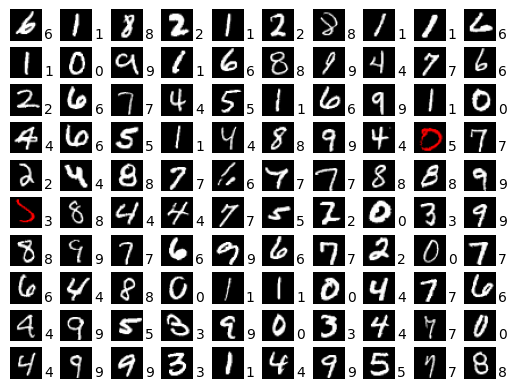

Train Epoch: 7 [0/60000 (0%)]	Loss: 0.000579
Train Epoch: 7 [6400/60000 (11%)]	Loss: 0.000285
Train Epoch: 7 [12800/60000 (21%)]	Loss: 0.000023
Train Epoch: 7 [19200/60000 (32%)]	Loss: 0.000520
Train Epoch: 7 [25600/60000 (43%)]	Loss: 0.000260
Train Epoch: 7 [32000/60000 (53%)]	Loss: 0.000313
Train Epoch: 7 [38400/60000 (64%)]	Loss: 0.000122
Train Epoch: 7 [44800/60000 (75%)]	Loss: 0.000370
Train Epoch: 7 [51200/60000 (85%)]	Loss: 0.002024
Train Epoch: 7 [57600/60000 (96%)]	Loss: 0.000177

Test set: Average loss: 0.0395, Accuracy: 9901/10000 (99.01%)



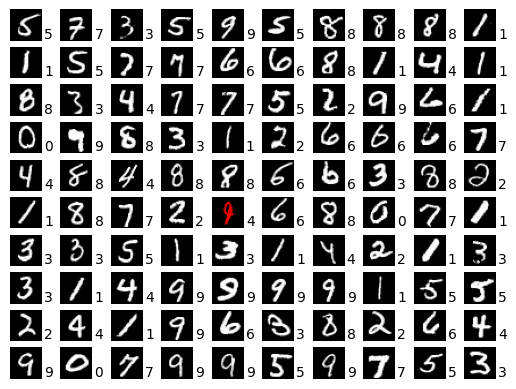

Train Epoch: 8 [0/60000 (0%)]	Loss: 0.009158
Train Epoch: 8 [6400/60000 (11%)]	Loss: 0.000627
Train Epoch: 8 [12800/60000 (21%)]	Loss: 0.000082
Train Epoch: 8 [19200/60000 (32%)]	Loss: 0.000028
Train Epoch: 8 [25600/60000 (43%)]	Loss: 0.000174
Train Epoch: 8 [32000/60000 (53%)]	Loss: 0.000280
Train Epoch: 8 [38400/60000 (64%)]	Loss: 0.000612
Train Epoch: 8 [44800/60000 (75%)]	Loss: 0.000274
Train Epoch: 8 [51200/60000 (85%)]	Loss: 0.000199
Train Epoch: 8 [57600/60000 (96%)]	Loss: 0.000221

Test set: Average loss: 0.0398, Accuracy: 9902/10000 (99.02%)



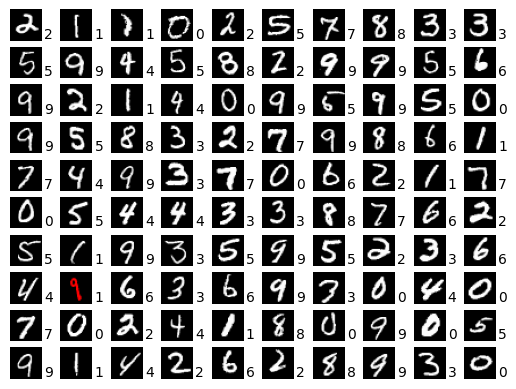

Train Epoch: 9 [0/60000 (0%)]	Loss: 0.000359
Train Epoch: 9 [6400/60000 (11%)]	Loss: 0.000561
Train Epoch: 9 [12800/60000 (21%)]	Loss: 0.000075
Train Epoch: 9 [19200/60000 (32%)]	Loss: 0.000179
Train Epoch: 9 [25600/60000 (43%)]	Loss: 0.001226
Train Epoch: 9 [32000/60000 (53%)]	Loss: 0.000163
Train Epoch: 9 [38400/60000 (64%)]	Loss: 0.000004
Train Epoch: 9 [44800/60000 (75%)]	Loss: 0.000119
Train Epoch: 9 [51200/60000 (85%)]	Loss: 0.000435
Train Epoch: 9 [57600/60000 (96%)]	Loss: 0.000217

Test set: Average loss: 0.0406, Accuracy: 9901/10000 (99.01%)



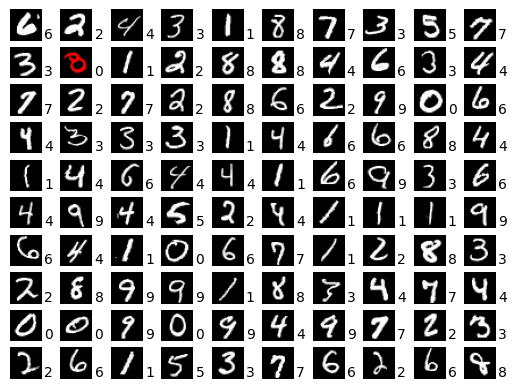

Train Epoch: 10 [0/60000 (0%)]	Loss: 0.000005
Train Epoch: 10 [6400/60000 (11%)]	Loss: 0.000617
Train Epoch: 10 [12800/60000 (21%)]	Loss: 0.000144
Train Epoch: 10 [19200/60000 (32%)]	Loss: 0.000158
Train Epoch: 10 [25600/60000 (43%)]	Loss: 0.000107
Train Epoch: 10 [32000/60000 (53%)]	Loss: 0.000031
Train Epoch: 10 [38400/60000 (64%)]	Loss: 0.000015
Train Epoch: 10 [44800/60000 (75%)]	Loss: 0.000518
Train Epoch: 10 [51200/60000 (85%)]	Loss: 0.000073
Train Epoch: 10 [57600/60000 (96%)]	Loss: 0.000142

Test set: Average loss: 0.0409, Accuracy: 9903/10000 (99.03%)



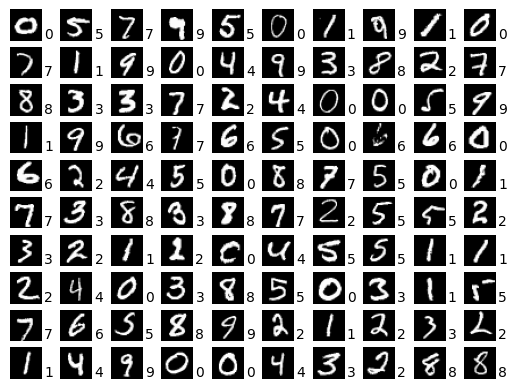

In [31]:
# hyper parameters
batch_size = 64
test_batch_size = 1000
epochs = 10
lr = 1.0
gamma = 0.7
log_interval = 100

# use GPU if available
use_cuda = torch.cuda.is_available()
print(use_cuda)
kwargs = {'num_workers': 1, 'pin_memory': True} if use_cuda else {}

# initialize data loaders
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=True, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])), batch_size=batch_size, shuffle=True, **kwargs)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=False, 
    transform=transforms.Compose([
        transforms.ToTensor(), 
        transforms.Normalize((0.1307,), (0.3081,))
    ])),
    batch_size=test_batch_size, shuffle=True, **kwargs)

model = ConvNet1()
if use_cuda:
    model = model.cuda()

# initialize optimizer and scheduler
optimizer = optim.Adadelta(model.parameters(), lr=lr)
scheduler = StepLR(optimizer, step_size=1, gamma=gamma)

for epoch in range(1, epochs + 1):
    # train one epoch
    train(model, use_cuda, train_loader, optimizer, epoch, log_interval)
    
    # run on test dataset
    validate(model, use_cuda, test_loader)
    scheduler.step()
    
    
    torch.save(model.state_dict(), "models/mnist/convnet1_checkpoint.pt")

#### Train ConvNet2

False
Train Epoch: 1 [0/60000 (0%)]	Loss: 2.443807
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.152094
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.103485
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.092727
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.125283
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.050348
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.078700
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.019587
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.053425
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.020083

Test set: Average loss: 0.0433, Accuracy: 9852/10000 (98.52%)



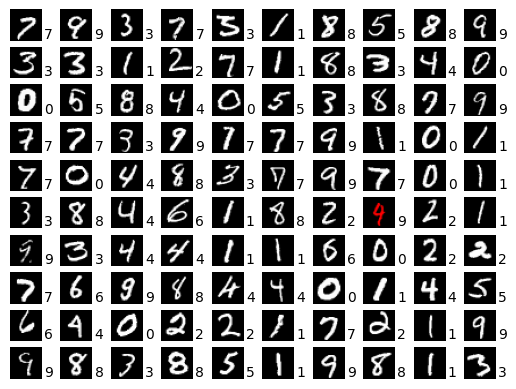

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.052573
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.032244
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.016169
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.002290
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.005596
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.001558
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.015048
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.004822
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.020984
Train Epoch: 2 [57600/60000 (96%)]	Loss: 0.013496

Test set: Average loss: 0.0315, Accuracy: 9888/10000 (98.88%)



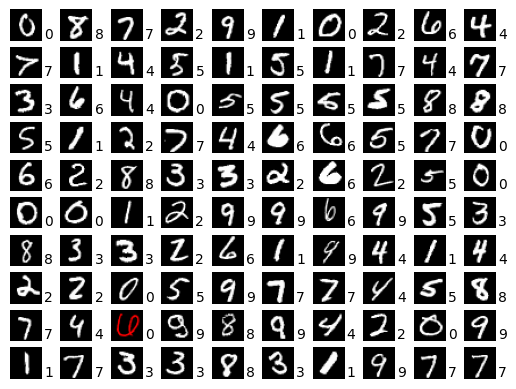

Train Epoch: 3 [0/60000 (0%)]	Loss: 0.003936
Train Epoch: 3 [6400/60000 (11%)]	Loss: 0.003776
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.001474
Train Epoch: 3 [19200/60000 (32%)]	Loss: 0.002527
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.010984
Train Epoch: 3 [32000/60000 (53%)]	Loss: 0.008705
Train Epoch: 3 [38400/60000 (64%)]	Loss: 0.002917
Train Epoch: 3 [44800/60000 (75%)]	Loss: 0.152386
Train Epoch: 3 [51200/60000 (85%)]	Loss: 0.017129
Train Epoch: 3 [57600/60000 (96%)]	Loss: 0.000896

Test set: Average loss: 0.0251, Accuracy: 9919/10000 (99.19%)



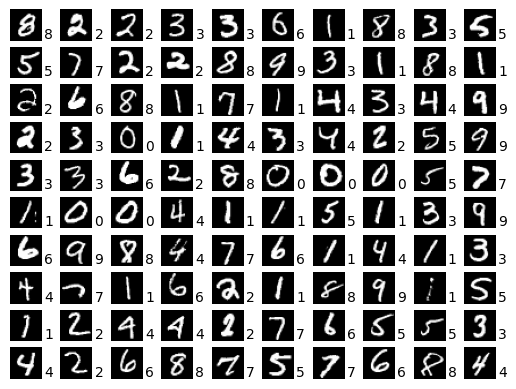

Train Epoch: 4 [0/60000 (0%)]	Loss: 0.018012
Train Epoch: 4 [6400/60000 (11%)]	Loss: 0.002638
Train Epoch: 4 [12800/60000 (21%)]	Loss: 0.015101
Train Epoch: 4 [19200/60000 (32%)]	Loss: 0.001688
Train Epoch: 4 [25600/60000 (43%)]	Loss: 0.082700
Train Epoch: 4 [32000/60000 (53%)]	Loss: 0.001229
Train Epoch: 4 [38400/60000 (64%)]	Loss: 0.001108
Train Epoch: 4 [44800/60000 (75%)]	Loss: 0.001823
Train Epoch: 4 [51200/60000 (85%)]	Loss: 0.057470
Train Epoch: 4 [57600/60000 (96%)]	Loss: 0.003121

Test set: Average loss: 0.0253, Accuracy: 9921/10000 (99.21%)



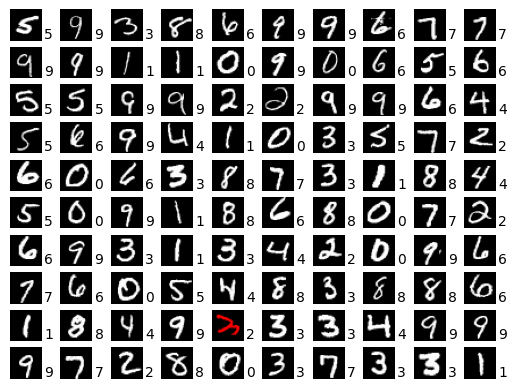

Train Epoch: 5 [0/60000 (0%)]	Loss: 0.001955
Train Epoch: 5 [6400/60000 (11%)]	Loss: 0.004085
Train Epoch: 5 [12800/60000 (21%)]	Loss: 0.022738
Train Epoch: 5 [19200/60000 (32%)]	Loss: 0.001092
Train Epoch: 5 [25600/60000 (43%)]	Loss: 0.001838
Train Epoch: 5 [32000/60000 (53%)]	Loss: 0.004418
Train Epoch: 5 [38400/60000 (64%)]	Loss: 0.001531
Train Epoch: 5 [44800/60000 (75%)]	Loss: 0.000975
Train Epoch: 5 [51200/60000 (85%)]	Loss: 0.001431
Train Epoch: 5 [57600/60000 (96%)]	Loss: 0.003621

Test set: Average loss: 0.0255, Accuracy: 9917/10000 (99.17%)



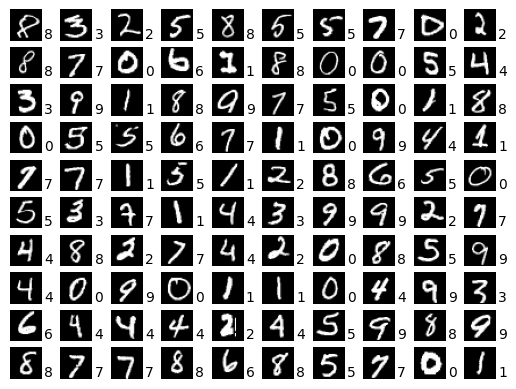

Train Epoch: 6 [0/60000 (0%)]	Loss: 0.002980
Train Epoch: 6 [6400/60000 (11%)]	Loss: 0.001462
Train Epoch: 6 [12800/60000 (21%)]	Loss: 0.009733
Train Epoch: 6 [19200/60000 (32%)]	Loss: 0.000961
Train Epoch: 6 [25600/60000 (43%)]	Loss: 0.000244
Train Epoch: 6 [32000/60000 (53%)]	Loss: 0.000638
Train Epoch: 6 [38400/60000 (64%)]	Loss: 0.002206
Train Epoch: 6 [44800/60000 (75%)]	Loss: 0.007759
Train Epoch: 6 [51200/60000 (85%)]	Loss: 0.001560
Train Epoch: 6 [57600/60000 (96%)]	Loss: 0.001147

Test set: Average loss: 0.0266, Accuracy: 9919/10000 (99.19%)



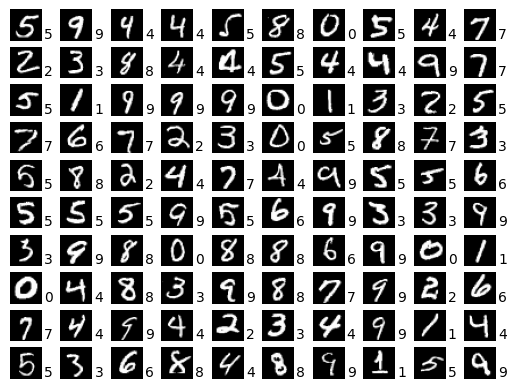

Train Epoch: 7 [0/60000 (0%)]	Loss: 0.000367
Train Epoch: 7 [6400/60000 (11%)]	Loss: 0.000438
Train Epoch: 7 [12800/60000 (21%)]	Loss: 0.000214
Train Epoch: 7 [19200/60000 (32%)]	Loss: 0.001740
Train Epoch: 7 [25600/60000 (43%)]	Loss: 0.002716
Train Epoch: 7 [32000/60000 (53%)]	Loss: 0.002434
Train Epoch: 7 [38400/60000 (64%)]	Loss: 0.000351
Train Epoch: 7 [44800/60000 (75%)]	Loss: 0.004945
Train Epoch: 7 [51200/60000 (85%)]	Loss: 0.001917
Train Epoch: 7 [57600/60000 (96%)]	Loss: 0.004649

Test set: Average loss: 0.0263, Accuracy: 9917/10000 (99.17%)



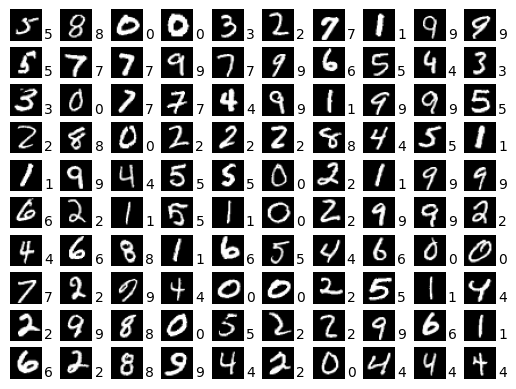

Train Epoch: 8 [0/60000 (0%)]	Loss: 0.001735
Train Epoch: 8 [6400/60000 (11%)]	Loss: 0.000349
Train Epoch: 8 [12800/60000 (21%)]	Loss: 0.001794
Train Epoch: 8 [19200/60000 (32%)]	Loss: 0.000795
Train Epoch: 8 [25600/60000 (43%)]	Loss: 0.000198
Train Epoch: 8 [32000/60000 (53%)]	Loss: 0.005267
Train Epoch: 8 [38400/60000 (64%)]	Loss: 0.000415
Train Epoch: 8 [44800/60000 (75%)]	Loss: 0.001955
Train Epoch: 8 [51200/60000 (85%)]	Loss: 0.001294
Train Epoch: 8 [57600/60000 (96%)]	Loss: 0.000577

Test set: Average loss: 0.0263, Accuracy: 9926/10000 (99.26%)



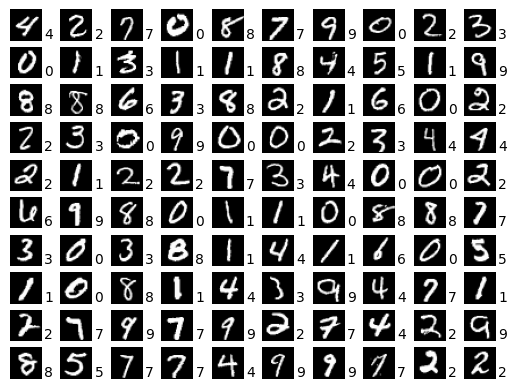

Train Epoch: 9 [0/60000 (0%)]	Loss: 0.002330
Train Epoch: 9 [6400/60000 (11%)]	Loss: 0.000404
Train Epoch: 9 [12800/60000 (21%)]	Loss: 0.005310
Train Epoch: 9 [19200/60000 (32%)]	Loss: 0.000739
Train Epoch: 9 [25600/60000 (43%)]	Loss: 0.000965
Train Epoch: 9 [32000/60000 (53%)]	Loss: 0.000230
Train Epoch: 9 [38400/60000 (64%)]	Loss: 0.000280
Train Epoch: 9 [44800/60000 (75%)]	Loss: 0.002361
Train Epoch: 9 [51200/60000 (85%)]	Loss: 0.001080
Train Epoch: 9 [57600/60000 (96%)]	Loss: 0.000910

Test set: Average loss: 0.0264, Accuracy: 9926/10000 (99.26%)



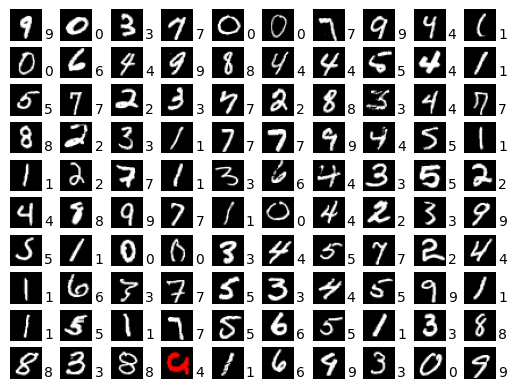

Train Epoch: 10 [0/60000 (0%)]	Loss: 0.000473
Train Epoch: 10 [6400/60000 (11%)]	Loss: 0.001870
Train Epoch: 10 [12800/60000 (21%)]	Loss: 0.003019
Train Epoch: 10 [19200/60000 (32%)]	Loss: 0.000744
Train Epoch: 10 [25600/60000 (43%)]	Loss: 0.000862
Train Epoch: 10 [32000/60000 (53%)]	Loss: 0.004188
Train Epoch: 10 [38400/60000 (64%)]	Loss: 0.004105
Train Epoch: 10 [44800/60000 (75%)]	Loss: 0.000165
Train Epoch: 10 [51200/60000 (85%)]	Loss: 0.002096
Train Epoch: 10 [57600/60000 (96%)]	Loss: 0.000170

Test set: Average loss: 0.0261, Accuracy: 9927/10000 (99.27%)



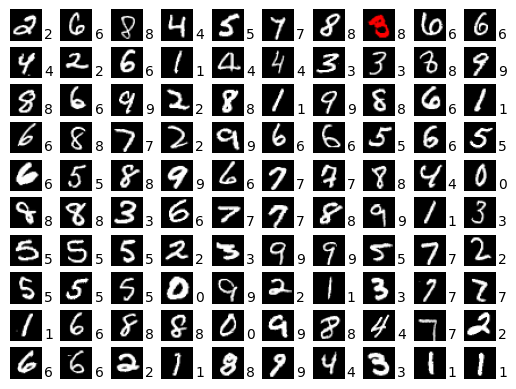

In [32]:
# hyper parameters
batch_size = 64
test_batch_size = 1000
epochs = 10
lr = 1.0
gamma = 0.7
log_interval = 100

# use GPU if available
use_cuda = torch.cuda.is_available()
print(use_cuda)
kwargs = {'num_workers': 1, 'pin_memory': True} if use_cuda else {}

# initialize data loaders
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=True, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])), batch_size=batch_size, shuffle=True, **kwargs)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=False, 
    transform=transforms.Compose([
        transforms.ToTensor(), 
        transforms.Normalize((0.1307,), (0.3081,))
    ])),
    batch_size=test_batch_size, shuffle=True, **kwargs)

model = ConvNet2()
if use_cuda:
    model = model.cuda()

# initialize optimizer and scheduler
optimizer = optim.Adadelta(model.parameters(), lr=lr)
scheduler = StepLR(optimizer, step_size=1, gamma=gamma)

for epoch in range(1, epochs + 1):
    # train one epoch
    train(model, use_cuda, train_loader, optimizer, epoch, log_interval)
    
    # run on test dataset
    validate(model, use_cuda, test_loader)
    scheduler.step()
    
    
    torch.save(model.state_dict(), "models/mnist/convnet2_checkpoint.pt")

#### Train ConvNet3

False
Train Epoch: 1 [0/60000 (0%)]	Loss: 2.413544
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.071750
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.023061
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.083438
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.068834
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.067788
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.204813
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.070666
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.096940
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.050418

Test set: Average loss: 0.0406, Accuracy: 9864/10000 (98.64%)



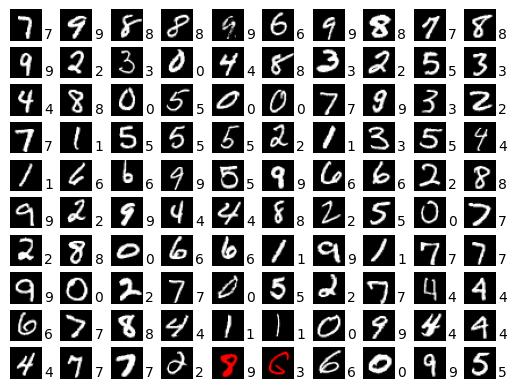

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.098751
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.051154
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.037113
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.002080
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.010441
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.001596
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.002682
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.007885
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.004064
Train Epoch: 2 [57600/60000 (96%)]	Loss: 0.031627

Test set: Average loss: 0.0277, Accuracy: 9908/10000 (99.08%)



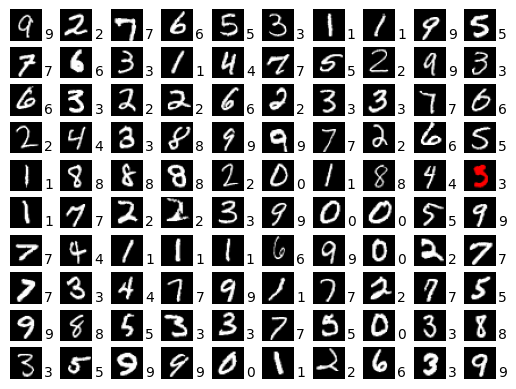

Train Epoch: 3 [0/60000 (0%)]	Loss: 0.004211
Train Epoch: 3 [6400/60000 (11%)]	Loss: 0.014780
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.025807
Train Epoch: 3 [19200/60000 (32%)]	Loss: 0.002117
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.005471
Train Epoch: 3 [32000/60000 (53%)]	Loss: 0.003747
Train Epoch: 3 [38400/60000 (64%)]	Loss: 0.001729
Train Epoch: 3 [44800/60000 (75%)]	Loss: 0.003228
Train Epoch: 3 [51200/60000 (85%)]	Loss: 0.012172
Train Epoch: 3 [57600/60000 (96%)]	Loss: 0.001954

Test set: Average loss: 0.0259, Accuracy: 9918/10000 (99.18%)



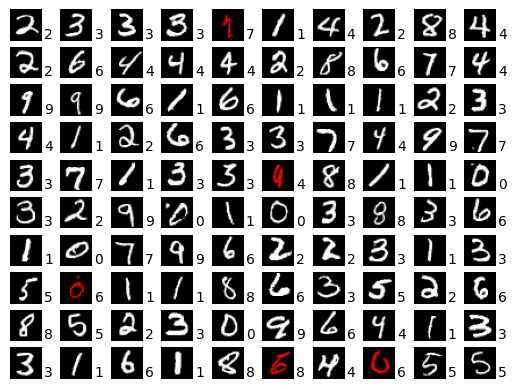

Train Epoch: 4 [0/60000 (0%)]	Loss: 0.005950
Train Epoch: 4 [6400/60000 (11%)]	Loss: 0.004775
Train Epoch: 4 [12800/60000 (21%)]	Loss: 0.001577
Train Epoch: 4 [19200/60000 (32%)]	Loss: 0.000798
Train Epoch: 4 [25600/60000 (43%)]	Loss: 0.001251
Train Epoch: 4 [32000/60000 (53%)]	Loss: 0.000335
Train Epoch: 4 [38400/60000 (64%)]	Loss: 0.004934
Train Epoch: 4 [44800/60000 (75%)]	Loss: 0.009366
Train Epoch: 4 [51200/60000 (85%)]	Loss: 0.001870
Train Epoch: 4 [57600/60000 (96%)]	Loss: 0.004448

Test set: Average loss: 0.0254, Accuracy: 9920/10000 (99.20%)



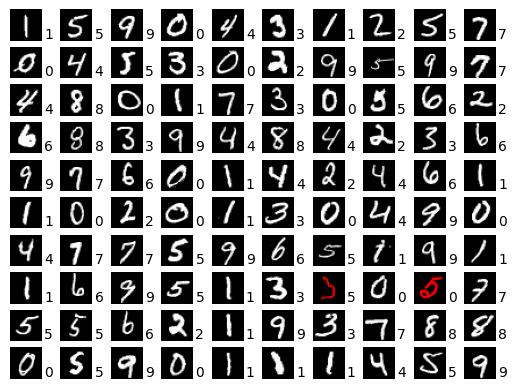

Train Epoch: 5 [0/60000 (0%)]	Loss: 0.003748
Train Epoch: 5 [6400/60000 (11%)]	Loss: 0.000577
Train Epoch: 5 [12800/60000 (21%)]	Loss: 0.001321
Train Epoch: 5 [19200/60000 (32%)]	Loss: 0.000990
Train Epoch: 5 [25600/60000 (43%)]	Loss: 0.001968
Train Epoch: 5 [32000/60000 (53%)]	Loss: 0.000972
Train Epoch: 5 [38400/60000 (64%)]	Loss: 0.001185
Train Epoch: 5 [44800/60000 (75%)]	Loss: 0.017493
Train Epoch: 5 [51200/60000 (85%)]	Loss: 0.000388
Train Epoch: 5 [57600/60000 (96%)]	Loss: 0.013004

Test set: Average loss: 0.0257, Accuracy: 9925/10000 (99.25%)



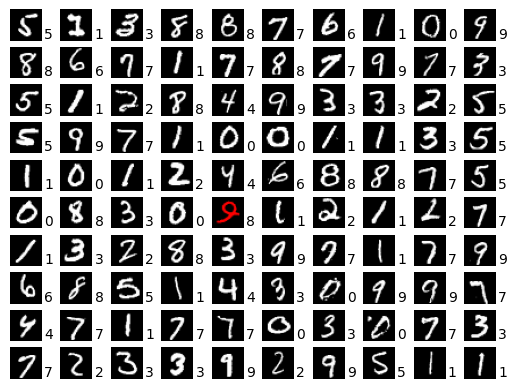

Train Epoch: 6 [0/60000 (0%)]	Loss: 0.000482
Train Epoch: 6 [6400/60000 (11%)]	Loss: 0.000793
Train Epoch: 6 [12800/60000 (21%)]	Loss: 0.001824
Train Epoch: 6 [19200/60000 (32%)]	Loss: 0.001646
Train Epoch: 6 [25600/60000 (43%)]	Loss: 0.003962
Train Epoch: 6 [32000/60000 (53%)]	Loss: 0.000687
Train Epoch: 6 [38400/60000 (64%)]	Loss: 0.000831
Train Epoch: 6 [44800/60000 (75%)]	Loss: 0.002087
Train Epoch: 6 [51200/60000 (85%)]	Loss: 0.001107
Train Epoch: 6 [57600/60000 (96%)]	Loss: 0.001844

Test set: Average loss: 0.0270, Accuracy: 9916/10000 (99.16%)



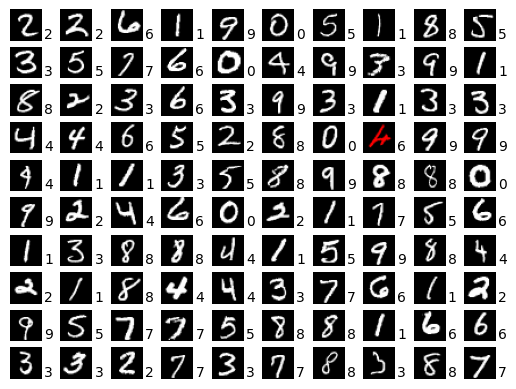

Train Epoch: 7 [0/60000 (0%)]	Loss: 0.000853
Train Epoch: 7 [6400/60000 (11%)]	Loss: 0.003338
Train Epoch: 7 [12800/60000 (21%)]	Loss: 0.000397
Train Epoch: 7 [19200/60000 (32%)]	Loss: 0.003268
Train Epoch: 7 [25600/60000 (43%)]	Loss: 0.000601
Train Epoch: 7 [32000/60000 (53%)]	Loss: 0.000158
Train Epoch: 7 [38400/60000 (64%)]	Loss: 0.001027
Train Epoch: 7 [44800/60000 (75%)]	Loss: 0.000538
Train Epoch: 7 [51200/60000 (85%)]	Loss: 0.000752
Train Epoch: 7 [57600/60000 (96%)]	Loss: 0.012025

Test set: Average loss: 0.0254, Accuracy: 9915/10000 (99.15%)



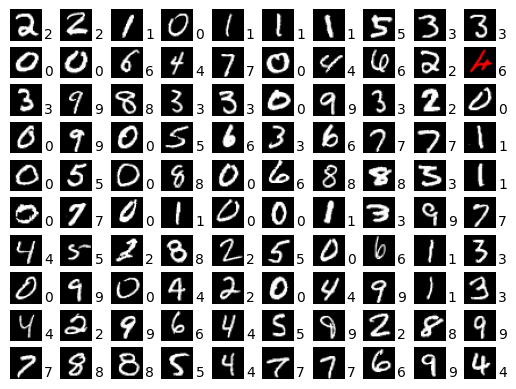

Train Epoch: 8 [0/60000 (0%)]	Loss: 0.001076
Train Epoch: 8 [6400/60000 (11%)]	Loss: 0.001115
Train Epoch: 8 [12800/60000 (21%)]	Loss: 0.000617
Train Epoch: 8 [19200/60000 (32%)]	Loss: 0.000438
Train Epoch: 8 [25600/60000 (43%)]	Loss: 0.004239
Train Epoch: 8 [32000/60000 (53%)]	Loss: 0.002990
Train Epoch: 8 [38400/60000 (64%)]	Loss: 0.021167
Train Epoch: 8 [44800/60000 (75%)]	Loss: 0.001938
Train Epoch: 8 [51200/60000 (85%)]	Loss: 0.002170
Train Epoch: 8 [57600/60000 (96%)]	Loss: 0.001370

Test set: Average loss: 0.0266, Accuracy: 9920/10000 (99.20%)



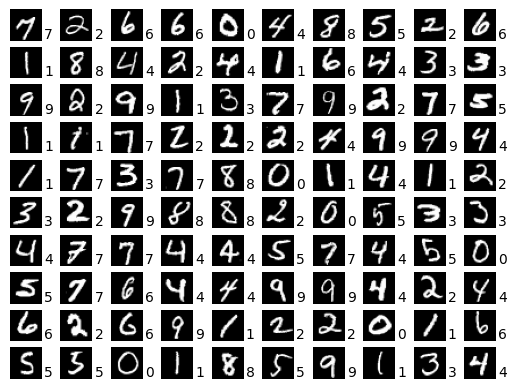

Train Epoch: 9 [0/60000 (0%)]	Loss: 0.000353
Train Epoch: 9 [6400/60000 (11%)]	Loss: 0.000278
Train Epoch: 9 [12800/60000 (21%)]	Loss: 0.000780
Train Epoch: 9 [19200/60000 (32%)]	Loss: 0.002378
Train Epoch: 9 [25600/60000 (43%)]	Loss: 0.000812
Train Epoch: 9 [32000/60000 (53%)]	Loss: 0.000522
Train Epoch: 9 [38400/60000 (64%)]	Loss: 0.000345
Train Epoch: 9 [44800/60000 (75%)]	Loss: 0.000113
Train Epoch: 9 [51200/60000 (85%)]	Loss: 0.001400
Train Epoch: 9 [57600/60000 (96%)]	Loss: 0.000160

Test set: Average loss: 0.0265, Accuracy: 9920/10000 (99.20%)



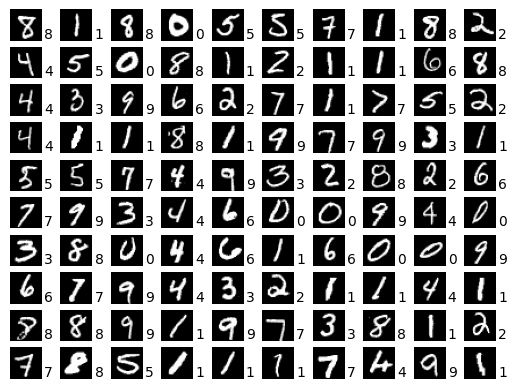

Train Epoch: 10 [0/60000 (0%)]	Loss: 0.003001
Train Epoch: 10 [6400/60000 (11%)]	Loss: 0.049543
Train Epoch: 10 [12800/60000 (21%)]	Loss: 0.000476
Train Epoch: 10 [19200/60000 (32%)]	Loss: 0.000027
Train Epoch: 10 [25600/60000 (43%)]	Loss: 0.002168
Train Epoch: 10 [32000/60000 (53%)]	Loss: 0.001639
Train Epoch: 10 [38400/60000 (64%)]	Loss: 0.000875
Train Epoch: 10 [44800/60000 (75%)]	Loss: 0.000673
Train Epoch: 10 [51200/60000 (85%)]	Loss: 0.000190
Train Epoch: 10 [57600/60000 (96%)]	Loss: 0.001376

Test set: Average loss: 0.0262, Accuracy: 9920/10000 (99.20%)



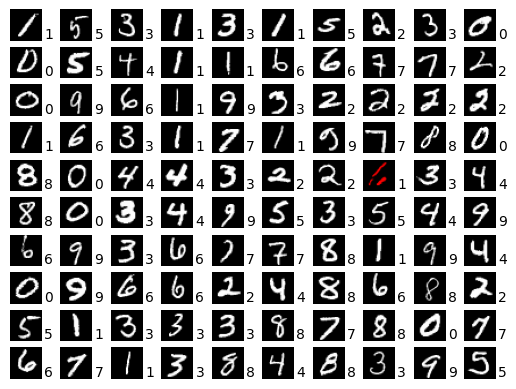

In [33]:
# hyper parameters
batch_size = 64
test_batch_size = 1000
epochs = 10
lr = 1.0
gamma = 0.7
log_interval = 100

# use GPU if available
use_cuda = torch.cuda.is_available()
print(use_cuda)
kwargs = {'num_workers': 1, 'pin_memory': True} if use_cuda else {}

# initialize data loaders
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=True, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])), batch_size=batch_size, shuffle=True, **kwargs)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=False, 
    transform=transforms.Compose([
        transforms.ToTensor(), 
        transforms.Normalize((0.1307,), (0.3081,))
    ])),
    batch_size=test_batch_size, shuffle=True, **kwargs)

model = ConvNet3()
if use_cuda:
    model = model.cuda()

# initialize optimizer and scheduler
optimizer = optim.Adadelta(model.parameters(), lr=lr)
scheduler = StepLR(optimizer, step_size=1, gamma=gamma)

for epoch in range(1, epochs + 1):
    # train one epoch
    train(model, use_cuda, train_loader, optimizer, epoch, log_interval)
    
    # run on test dataset
    validate(model, use_cuda, test_loader)
    scheduler.step()
    
    
    torch.save(model.state_dict(), "models/mnist/convnet3_checkpoint.pt")